<a href="https://colab.research.google.com/github/ramya-ganesan/AI-Powered-Healthcare-Data-Insights-Dashboard-/blob/main/Main_project_of_food_basket_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data-Driven Analysis of Food Basket Price Changes Across Countries**

#Domain

food security and economic monitoring

#Objective

The primary objective of this project is to analyze and classify changes in food basket prices across different countries over time using bi-weekly market monitoring data.

# to find specific objects:
1. To track percentage changes in food basket costs at the country level.

2. To categorize price changes into five severity levels:
Negative (<0%), Normal (0–3%), Moderate (3–10%), High (10–25%), and Severe (>25%).

3. To identify countries and periods experiencing high or severe food price inflation.

4. To support early warning and decision-making for food security interventions and economic planning.

5. To provide data-driven insights through classification and visualization of food price volatility trends.


#Dataset information

Source : The Humanitarian Data Exchange

Location : Country-level market data collected from local food markets across multiple countries worldwide

Year/Timeline : 19 May 2021 - 16 December 2025

#**Stage 1**
**Problem Definition**

1. Food basket prices vary significantly across countries and time.

2. Sharp price increases can threaten food security.

3. A systematic method is needed to monitor and classify price changes by severity.

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
url = "https://raw.githubusercontent.com/ramya-ganesan/Data-Driven-Analysis-of-Food-Basket-Price-Changes-Across-Countries/main/global-market-monitor.csv"

df = pd.read_csv(url, sep=',')   # separator fix
df

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,YoYChangeQuarter,YoYChangeMonth,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate
0,#date,#indicator+foodbasket+version,#meta+frequency,#country+code,#country+name,#adm1+name,#meta+level,#indicator+foodbasket+type,#indicator+foodbasket+price+type,#indicator+foodbasket+calories,...,#indicator+foodbasket+quarterly+change+yoy+num,#indicator+foodbasket+monthly+change+yoy+num,#indicator+foodbasket+quarterly+trend,#indicator+foodbasket+monthly+trend,#indicator+foodbasket+quarterly+share+num,#indicator+foodbasket+quarterly+change+num,#indicator+foodbasket+quarterly+change+code,#indicator+foodbasket+monthly+change+num,#indicator+foodbasket+monthly+change+code,#date+modified
1,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Bread,Retail,58.0,...,14.0,13.0,Normal,Normal,79.0,1.0,Normal,-1.0,Negative,2021-05-19 16:55:26.870
2,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Rice (low quality),Retail,22.0,...,7.0,6.0,Normal,Negative,21.0,NaN,Normal,NaN,Negative,2021-05-19 16:55:26.870
3,2021-03-01,55,Monthly,8,Angola,National Average,National,Cassava flour,Retail,19.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.883
4,2021-03-01,55,Monthly,8,Angola,National Average,National,Bread,Retail,13.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11649,2025-11-01,111,Monthly,257,United Republic of Tanzania,National Average,National,Maize,Wholesale,26.0,...,16.0,10.0,Negative,Negative,29.0,NaN,Negative,NaN,Normal,2025-12-16 16:30:24.947
11650,2025-11-01,111,Monthly,269,Yemen,National Average,National,Oil (vegetable),Retail,9.0,...,-11.0,-11.0,Negative,N/A,12.0,NaN,Negative,NaN,N/A,2025-12-16 16:30:25.030
11651,2025-11-01,111,Monthly,269,Yemen,National Average,National,Sugar,Retail,12.0,...,-22.0,-25.0,Negative,N/A,22.0,NaN,Negative,NaN,N/A,2025-12-16 16:30:25.037
11652,2025-11-01,111,Monthly,269,Yemen,National Average,National,Wheat flour,Retail,38.0,...,-19.0,-20.0,Negative,N/A,46.0,-32.0,Negative,NaN,N/A,2025-12-16 16:30:25.037


In [ ]:
# drop the first row (metadata row)
df = df.drop(index=0).reset_index(drop=True)

df.head()

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,YoYChangeQuarter,YoYChangeMonth,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate
0,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Bread,Retail,58.0,...,14.0,13.0,Normal,Normal,79.0,1.0,Normal,-1.0,Negative,2021-05-19 16:55:26.870
1,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Rice (low quality),Retail,22.0,...,7.0,6.0,Normal,Negative,21.0,NaN,Normal,NaN,Negative,2021-05-19 16:55:26.870
2,2021-03-01,55,Monthly,8,Angola,National Average,National,Cassava flour,Retail,19.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.883
3,2021-03-01,55,Monthly,8,Angola,National Average,National,Bread,Retail,13.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887
4,2021-03-01,55,Monthly,8,Angola,National Average,National,Sugar (white),Retail,7.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887


#Dataset description

Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11653 entries, 0 to 11652
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Date                      11653 non-null  object
 1   MonthlyVersion            11653 non-null  object
 2   FrequencyName             11653 non-null  object
 3   CountryCode               11653 non-null  object
 4   CountryName               11653 non-null  object
 5   Admin1                    11653 non-null  object
 6   DataLevel                 11653 non-null  object
 7   MainStapleFood            11653 non-null  object
 8   PriceType                 11653 non-null  object
 9   CaloricContribution       11626 non-null  object
 10  QuarterlyChangeNSA        9950 non-null   object
 11  MonthlyChangeNSA          6485 non-null   object
 12  QuarterlyChangeSA         9924 non-null   object
 13  MonthlyChangeSA           6461 non-null   object
 14  YoYChangeQuarter      

In [ ]:
df.head()

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,YoYChangeQuarter,YoYChangeMonth,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate
0,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Bread,Retail,58.0,...,14.0,13.0,Normal,Normal,79.0,1.0,Normal,-1.0,Negative,2021-05-19 16:55:26.870
1,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Rice (low quality),Retail,22.0,...,7.0,6.0,Normal,Negative,21.0,NaN,Normal,NaN,Negative,2021-05-19 16:55:26.870
2,2021-03-01,55,Monthly,8,Angola,National Average,National,Cassava flour,Retail,19.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.883
3,2021-03-01,55,Monthly,8,Angola,National Average,National,Bread,Retail,13.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887
4,2021-03-01,55,Monthly,8,Angola,National Average,National,Sugar (white),Retail,7.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887


In [ ]:
# Examine Statistical summary with df.describe()
df.describe()

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,YoYChangeQuarter,YoYChangeMonth,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate
count,11653,11653,11653,11653,11653,11653,11653,11653,11653,11626,...,9867,9829,11653,11653,9945,3226,11653,2139,11653,11653
unique,62,62,1,81,81,2,1,84,2,50,...,376,344,6,6,96,115,7,73,7,4781
top,2020-10-01,50,Monthly,159,Mauritania,National Average,National,Sugar,Retail,8.0,...,2.0,1.0,Negative,N/A,100.0,0.0,Negative,0.0,N/A,2025-02-03 12:25:18.257
freq,246,246,11653,422,422,6378,11653,1086,10121,1063,...,315,300,4198,5168,484,253,3981,311,3392,10


In [ ]:
# Calculate number of Rows and Columns with df.shape
df.shape

(11653, 24)

In [ ]:
#null values
df.isnull().sum()

,0
Date,0
MonthlyVersion,0
FrequencyName,0
CountryCode,0
CountryName,0
Admin1,0
DataLevel,0
MainStapleFood,0
PriceType,0
CaloricContribution,27


In [ ]:
#duplicate check
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,YoYChangeQuarter,YoYChangeMonth,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate
count,11653,11653,11653,11653,11653,11653,11653,11653,11653,11626,...,9867,9829,11653,11653,9945,3226,11653,2139,11653,11653
unique,62,62,1,81,81,2,1,84,2,50,...,376,344,6,6,96,115,7,73,7,4781
top,2020-10-01,50,Monthly,159,Mauritania,National Average,National,Sugar,Retail,8.0,...,2.0,1.0,Negative,N/A,100.0,0.0,Negative,0.0,N/A,2025-02-03 12:25:18.257
freq,246,246,11653,422,422,6378,11653,1086,10121,1063,...,315,300,4198,5168,484,253,3981,311,3392,10


stage 1 completed............

#**Stage 2**
**Data Cleaning and Pre-processing**

In [ ]:
#datatype change
df.dtypes

,0
Date,object
MonthlyVersion,object
FrequencyName,object
CountryCode,object
CountryName,object
Admin1,object
DataLevel,object
MainStapleFood,object
PriceType,object
CaloricContribution,object


In [ ]:
df.columns

Index(['Date', 'MonthlyVersion', 'FrequencyName', 'CountryCode', 'CountryName',
       'Admin1', 'DataLevel', 'MainStapleFood', 'PriceType',
       'CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA',
       'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter',
       'YoYChangeMonth', 'PriceTrendQuarter', 'PriceTrendMonth',
       'QuarterlyCostShare', 'TotImpactQuarterlyChange',
       'TotImpactQuarterlyCode', 'TotImpactMonthlyChange',
       'TotImpactMonthlyCode', 'LastModifyDate'],
      dtype='object')

In [ ]:
#convert data types date and last modified date columns

date_cols = ['Date', 'LastModifyDate']

df[date_cols] = (
    df[date_cols]
    .apply(pd.to_datetime, errors='coerce')
    .astype('datetime64[ns]')
)


In [ ]:
#convert numerical columns datatypes change into float
numeric_cols = [
    'CaloricContribution',
    'QuarterlyChangeNSA',
    'MonthlyChangeNSA',
    'QuarterlyChangeSA',
    'MonthlyChangeSA',
    'YoYChangeQuarter',
    'YoYChangeMonth',
    'QuarterlyCostShare',
    'TotImpactQuarterlyChange',
    'TotImpactMonthlyChange'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')


In [ ]:
#change datatype int
int_cols = ['CountryCode', 'MonthlyVersion']

df[int_cols] = (
    df[int_cols]
    .apply(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

In [ ]:
df['Year'] = df['Date'].dt.year

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['MonthName'] = df['Date'].dt.month_name()

In [ ]:
#datatype change
df.dtypes

,0
Date,datetime64[ns]
MonthlyVersion,Int64
FrequencyName,object
CountryCode,Int64
CountryName,object
Admin1,object
DataLevel,object
MainStapleFood,object
PriceType,object
CaloricContribution,float64


In [ ]:
#unique values of categorical column
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].unique()}")

FrequencyName: ['Monthly']
CountryName: ['Afghanistan' 'Angola' 'Armenia' 'Bangladesh' 'Benin' 'Burkina Faso'
 'Burundi' 'Cambodia' 'Cameroon' 'Cabo Verde' 'Central African Republic'
 'Chad' 'Colombia' 'Democratic Republic of the Congo' 'Djibouti'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Ethiopia'
 'Gambia (The)' 'Ghana' 'Guinea' 'Guinea Bissau' 'Haiti' 'Honduras'
 'India' 'Indonesia' 'Iraq' 'Jordan' 'Kenya' 'Kyrgyzstan'
 "Lao People's Democratic Republic" 'Lebanon' 'Lesotho' 'Libya'
 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mexico' 'Mozambique' 'Myanmar'
 'Namibia' 'Nepal' 'Nicaragua' 'Niger' 'Nigeria' 'Pakistan' 'Panama'
 'Peru' 'Philippines' 'Rwanda' 'Senegal' 'Sierra Leone' 'Somalia'
 'South Sudan' 'Sri Lanka' 'State of Palestine' 'Sudan'
 'Syrian Arab Republic' 'Tajikistan' 'Togo' 'Turkey' 'Uganda'
 'United Republic of Tanzania' 'Yemen' 'Zambia' 'Eswatini' 'Liberia'
 'Congo (Republic of)' 'Viet Nam' 'Algeria'
 'Bolivia (Plurinational State of)' "Cote d'Ivoire"
 'Ir

In [ ]:
#remove empty space in all columns row by row
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)



In [ ]:
#unique values of categorical column
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].unique()}")

FrequencyName: ['Monthly']
CountryName: ['Afghanistan' 'Angola' 'Armenia' 'Bangladesh' 'Benin' 'Burkina Faso'
 'Burundi' 'Cambodia' 'Cameroon' 'Cabo Verde' 'Central African Republic'
 'Chad' 'Colombia' 'Democratic Republic of the Congo' 'Djibouti'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Ethiopia'
 'Gambia (The)' 'Ghana' 'Guinea' 'Guinea Bissau' 'Haiti' 'Honduras'
 'India' 'Indonesia' 'Iraq' 'Jordan' 'Kenya' 'Kyrgyzstan'
 "Lao People's Democratic Republic" 'Lebanon' 'Lesotho' 'Libya'
 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mexico' 'Mozambique' 'Myanmar'
 'Namibia' 'Nepal' 'Nicaragua' 'Niger' 'Nigeria' 'Pakistan' 'Panama'
 'Peru' 'Philippines' 'Rwanda' 'Senegal' 'Sierra Leone' 'Somalia'
 'South Sudan' 'Sri Lanka' 'State of Palestine' 'Sudan'
 'Syrian Arab Republic' 'Tajikistan' 'Togo' 'Turkey' 'Uganda'
 'United Republic of Tanzania' 'Yemen' 'Zambia' 'Eswatini' 'Liberia'
 'Congo (Republic of)' 'Viet Nam' 'Algeria'
 'Bolivia (Plurinational State of)' "Cote d'Ivoire"
 'Ir

In [ ]:
df['TotImpactMonthlyCode'].unique()

array(['Negative', '', 'Normal', 'Moderate', 'N/A', 'High', 'Severe'],
      dtype=object)

In [ ]:
#handling missing values
#caloric_contribution value imputation
df['CaloricContribution'] = df['CaloricContribution'].fillna(
    df['CaloricContribution'].mean()
)

In [ ]:
#quarterly changesNSA (not seasonally adjusted) value imputation
#Group-wise median
df['QuarterlyChangeNSA'] = df['QuarterlyChangeNSA'].fillna(
    df.groupby('CountryName')['QuarterlyChangeNSA'].transform('median')
)

In [ ]:
#Global fallback for remaining NaNs
df['QuarterlyChangeNSA'] = df['QuarterlyChangeNSA'].fillna(
    df['QuarterlyChangeNSA'].mean()
)

In [ ]:
#Monthly changesNSA (not seasonally adjusted) value imputation
#Group-wise median
df['MonthlyChangeNSA'] = df['MonthlyChangeNSA'].fillna(
    df.groupby('CountryName')['MonthlyChangeNSA'].transform('median')
)


In [ ]:
#Global fallback for remaining NaNs
df['MonthlyChangeNSA'] = df['MonthlyChangeNSA'].fillna(df['MonthlyChangeNSA'].median())

In [ ]:
#quarterly changesSA (seasonally adjusted) value imputation
#Group-wise median
df['QuarterlyChangeSA'] = df['QuarterlyChangeSA'].fillna(
    df.groupby('CountryName')['QuarterlyChangeSA'].transform('median')
)

In [ ]:
#Global fallback for remaining NaNs
df['QuarterlyChangeSA'] = df['QuarterlyChangeSA'].fillna(df['QuarterlyChangeSA'].median())

In [ ]:
#monthly changesSA (seasonally adjusted) value imputation
#Group-wise median
df['MonthlyChangeSA'] = df['MonthlyChangeSA'].fillna(
    df.groupby('CountryName')['MonthlyChangeSA'].transform('median')
)

In [ ]:
#Global fallback for remaining NaNs
df['MonthlyChangeSA'] = df['MonthlyChangeSA'].fillna(df['MonthlyChangeSA'].median())

In [ ]:
#Year on Year ChangeQuarter value imputation
#groupwise median
df['YoYChangeQuarter'] = df['YoYChangeQuarter'].fillna(
    df.groupby('CountryName')['YoYChangeQuarter'].transform('median')
)


In [ ]:
#Global fallback for remaining NaNs
df['YoYChangeQuarter'] = df['YoYChangeQuarter'].fillna(df['YoYChangeQuarter'].median())

In [ ]:
#Year on Year Changemonth value imputation
#groupwise median
df['YoYChangeMonth'] = df['YoYChangeMonth'].fillna(
    df.groupby('CountryName')['YoYChangeMonth'].transform('median')
)

In [ ]:
#Global fallback for remaining NaNs
df['YoYChangeMonth'] = df['YoYChangeMonth'].fillna(df['YoYChangeMonth'].median())

In [ ]:
# QuarterlyCostShare value imputation
df['QuarterlyCostShare'] = df['QuarterlyCostShare'].fillna(
    df.groupby('CountryName')['QuarterlyCostShare'].transform('median')
)


In [ ]:
#remaining nans filling
df['QuarterlyCostShare'] = df['QuarterlyCostShare'].fillna(
    df['QuarterlyCostShare'].median()
)

In [ ]:
# TotImpactMonthlyChange value imputation
# Group-wise median based on 'CountryName' and 'MainStapleFood'
df['TotImpactMonthlyChange'] = df['TotImpactMonthlyChange'].fillna(
    df.groupby(['CountryName', 'MainStapleFood'])['TotImpactMonthlyChange'].transform('median')
)

In [ ]:
# Global fallback for remaining NaNs in 'TotImpactMonthlyChange'
df['TotImpactMonthlyChange'] = df['TotImpactMonthlyChange'].fillna(df['TotImpactMonthlyChange'].median())

In [ ]:
# TotImpactQuarterlyChange value imputation
# Group-wise median based on 'CountryName' and 'MainStapleFood'
df['TotImpactQuarterlyChange'] = df['TotImpactQuarterlyChange'].fillna(
    df.groupby(['CountryName', 'MainStapleFood'])['TotImpactQuarterlyChange'].transform('median')
)

In [ ]:
# Global fallback for remaining NaNs in 'TotImpactQuarterlyChange'
df['TotImpactQuarterlyChange'] = df['TotImpactQuarterlyChange'].fillna(df['TotImpactQuarterlyChange'].median())

In [ ]:
df.isna().sum()  #category col check

,0
Date,0
MonthlyVersion,0
FrequencyName,0
CountryCode,0
CountryName,0
Admin1,0
DataLevel,0
MainStapleFood,0
PriceType,0
CaloricContribution,0


In [ ]:
#category col check (N/A values )
for col_name in ['PriceTrendQuarter','TotImpactMonthlyCode','TotImpactQuarterlyCode','PriceTrendMonth']:
    print(f"{col_name}: {df[col_name].unique()}")

PriceTrendQuarter: ['Normal' 'N/A' 'Moderate' 'High' 'Negative' 'Severe']
TotImpactMonthlyCode: ['Negative' '' 'Normal' 'Moderate' 'N/A' 'High' 'Severe']
TotImpactQuarterlyCode: ['Normal' '' 'Moderate' 'High' 'Negative' 'Severe' 'N/A']
PriceTrendMonth: ['Normal' 'Negative' 'N/A' 'Moderate' 'High' 'Severe']


In [ ]:
df.replace(['N/A', ''], np.nan, inplace=True)

In [ ]:
#categorical columns nan value imputation
cat_cols = [
    'PriceTrendQuarter',
    'PriceTrendMonth',
    'TotImpactQuarterlyCode',
    'TotImpactMonthlyCode'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
#Recheck the missing value
df.isna().sum()

,0
Date,0
MonthlyVersion,0
FrequencyName,0
CountryCode,0
CountryName,0
Admin1,0
DataLevel,0
MainStapleFood,0
PriceType,0
CaloricContribution,0


In [ ]:
for col_name in ['PriceTrendQuarter','TotImpactMonthlyCode','TotImpactQuarterlyCode','PriceTrendMonth']:
    print(f"{col_name}: {df[col_name].unique()}")

PriceTrendQuarter: ['Normal' 'Negative' 'Moderate' 'High' 'Severe']
TotImpactMonthlyCode: ['Negative' 'Normal' 'Moderate' 'High' 'Severe']
TotImpactQuarterlyCode: ['Normal' 'Negative' 'Moderate' 'High' 'Severe']
PriceTrendMonth: ['Normal' 'Negative' 'Moderate' 'High' 'Severe']


In [ ]:
df

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate,Year,MonthName
0,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Bread,Retail,58.0,...,Normal,Normal,79.0,1.0,Normal,-1.0,Negative,2021-05-19 16:55:26.870,2021,March
1,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Rice (low quality),Retail,22.0,...,Normal,Negative,21.0,1.0,Normal,0.0,Negative,2021-05-19 16:55:26.870,2021,March
2,2021-03-01,55,Monthly,8,Angola,National Average,National,Cassava flour,Retail,19.0,...,Negative,Negative,39.0,1.0,Negative,0.0,Negative,2021-05-19 16:55:26.883,2021,March
3,2021-03-01,55,Monthly,8,Angola,National Average,National,Bread,Retail,13.0,...,Negative,Negative,39.0,4.0,Negative,2.0,Negative,2021-05-19 16:55:26.887,2021,March
4,2021-03-01,55,Monthly,8,Angola,National Average,National,Sugar (white),Retail,7.0,...,Negative,Negative,39.0,1.0,Negative,0.0,Negative,2021-05-19 16:55:26.887,2021,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11648,2025-11-01,111,Monthly,257,United Republic of Tanzania,National Average,National,Maize,Wholesale,26.0,...,Negative,Negative,29.0,1.0,Negative,0.0,Normal,2025-12-16 16:30:24.947,2025,November
11649,2025-11-01,111,Monthly,269,Yemen,National Average,National,Oil (vegetable),Retail,9.0,...,Negative,Negative,12.0,1.0,Negative,0.0,Negative,2025-12-16 16:30:25.030,2025,November
11650,2025-11-01,111,Monthly,269,Yemen,National Average,National,Sugar,Retail,12.0,...,Negative,Negative,22.0,1.0,Negative,0.0,Negative,2025-12-16 16:30:25.037,2025,November
11651,2025-11-01,111,Monthly,269,Yemen,National Average,National,Wheat flour,Retail,38.0,...,Negative,Negative,46.0,-32.0,Negative,0.5,Negative,2025-12-16 16:30:25.037,2025,November


In [ ]:
#Add new column for severity category based on yoychange quarterly
# Define bins and labels
bins = [-np.inf, 0, 3, 10, 25, np.inf]
labels = ['Negative', 'Normal', 'Moderate', 'High', 'Severe']

# Create Severity Category column
df['SeverityCategory'] = pd.cut(
    df['YoYChangeQuarter'],
    bins=bins,
    labels=labels
)

In [ ]:
#monthly severity
df['SeverityMonthly'] = pd.cut(
    df['MonthlyChangeNSA'],
    bins=bins,
    labels=labels
)

# **Stage 3**


**EDA , Statistical analysis & Visualizations**




**Exploratory Data Analysis (EDA)**

In [ ]:
# display essential information about your DataFrame. with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11653 entries, 0 to 11652
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      11653 non-null  datetime64[ns]
 1   MonthlyVersion            11653 non-null  Int64         
 2   FrequencyName             11653 non-null  object        
 3   CountryCode               11653 non-null  Int64         
 4   CountryName               11653 non-null  object        
 5   Admin1                    11653 non-null  object        
 6   DataLevel                 11653 non-null  object        
 7   MainStapleFood            11653 non-null  object        
 8   PriceType                 11653 non-null  object        
 9   CaloricContribution       11653 non-null  float64       
 10  QuarterlyChangeNSA        11653 non-null  float64       
 11  MonthlyChangeNSA          11653 non-null  float64       
 12  QuarterlyChangeSA 

In [ ]:
# Examine Statistical summary with df.describe()
df.describe()

,Date,MonthlyVersion,CountryCode,CaloricContribution,QuarterlyChangeNSA,MonthlyChangeNSA,QuarterlyChangeSA,MonthlyChangeSA,YoYChangeQuarter,YoYChangeMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactMonthlyChange,LastModifyDate,Year
count,11653,11653.0,11653.0,11653.000000,11653.000000,11653.000000,11653.000000,11653.000000,11653.000000,11653.000000,11653.000000,11653.000000,11653.000000,11653,11653.000000
mean,2023-01-19 23:42:34.569638656,77.640693,2163.429074,17.311887,4.201845,1.202909,2.472282,0.562001,21.472196,22.136746,32.358062,1.217412,0.115206,2023-04-02 01:24:53.249345792,2022.587488
min,2020-10-01 00:00:00,50.0,1.0,5.000000,-100.000000,-74.000000,-100.000000,-74.000000,-100.000000,-100.000000,2.000000,-100.000000,-71.000000,2021-05-19 16:55:26.870000,2020.000000
25%,2021-10-01 00:00:00,62.0,79.0,8.000000,-1.000000,0.000000,-3.000000,-1.000000,0.000000,0.000000,15.000000,1.000000,0.000000,2021-11-15 11:34:08.867000064,2021.000000
50%,2022-11-01 00:00:00,75.0,159.0,12.000000,1.000000,0.000000,1.000000,0.000000,8.000000,9.000000,24.500000,1.000000,0.000000,2023-01-13 12:10:04.780000,2022.000000
75%,2024-04-01 00:00:00,92.0,231.0,21.000000,7.000000,2.000000,5.000000,1.000000,25.000000,26.000000,44.000000,1.000000,0.000000,2024-06-17 13:04:40.320000,2024.000000
max,2025-11-01 00:00:00,111.0,70001.0,70.000000,658.000000,193.000000,847.000000,508.000000,1942.000000,1796.000000,100.000000,296.000000,114.000000,2025-12-16 16:30:25.037000,2025.000000
std,NaN,17.795513,10479.004149,14.047835,18.231328,6.690477,19.684661,9.044000,58.396412,60.344446,23.925105,7.453483,3.435756,NaN,1.506766


In [ ]:
# Calculate number of Rows and Columns with df.shape
df.shape

(11653, 28)

**Statistical analysis for numerical columns**

In [ ]:
# Compute statistics
mean_values = df[cols].mean()
median_values = df[cols].median()
var_values = df[cols].var()
std_values = df[cols].std()
skew_values = df[cols].skew()
kurt_values = df[cols].kurt()

In [ ]:
# MEASURE OF CENTRAL TENDENCY
print('Mean:')
print(df[['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']].mean())
print('\nMedian:')
print(df[['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']].median())
print('\nMode:')
print(df[['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']].mode().iloc[0]) # .iloc[0] to get the first mode if there are multiple

Mean:
CaloricContribution         17.311887
QuarterlyChangeNSA           4.201845
MonthlyChangeNSA             1.202909
QuarterlyChangeSA            2.472282
MonthlyChangeSA              0.562001
YoYChangeQuarter            21.472196
YoYChangeMonth              22.136746
QuarterlyCostShare          32.358062
TotImpactQuarterlyChange     1.217412
TotImpactMonthlyChange       0.115206
dtype: float64

Median:
CaloricContribution         12.0
QuarterlyChangeNSA           1.0
MonthlyChangeNSA             0.0
QuarterlyChangeSA            1.0
MonthlyChangeSA              0.0
YoYChangeQuarter             8.0
YoYChangeMonth               9.0
QuarterlyCostShare          24.5
TotImpactQuarterlyChange     1.0
TotImpactMonthlyChange       0.0
dtype: float64

Mode:
CaloricContribution           8.0
QuarterlyChangeNSA            1.0
MonthlyChangeNSA              0.0
QuarterlyChangeSA             0.0
MonthlyChangeSA               0.0
YoYChangeQuarter              7.0
YoYChangeMonth                0.0


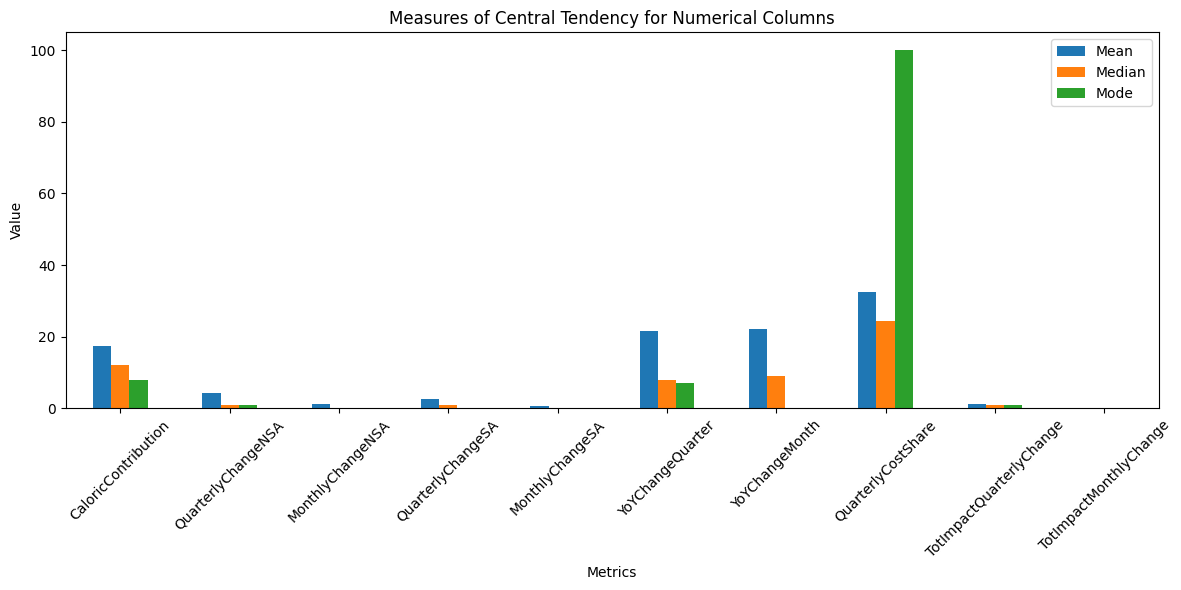

In [ ]:
cols = ['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']

mean = df[cols].mean()
median = df[cols].median()
mode = df[cols].mode().iloc[0]

df_stats = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Mode": mode
})

df_stats.plot(kind='bar', figsize=(12,6))
plt.xticks(rotation=45)
plt.title('Measures of Central Tendency for Numerical Columns')
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.tight_layout()
plt.show()

Since the mean is consistently higher than the median across most variables, the data shows positive skewness with some high-value outliers influencing quarterly and yearly change metrics.

1. Mean > Median → Indicates positive (right) skewness

2. Large gap in YoYChangeQuarter & YoYChangeMonth → Strong influence of high extreme values



In [ ]:
# Skewness and Kurtosis
print('Skewness:')
print(df[['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']].skew())
print('\nKurtosis:')
print(df[['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']].kurt())

Skewness:
CaloricContribution          1.690907
QuarterlyChangeNSA          11.659527
MonthlyChangeNSA             4.593970
QuarterlyChangeSA           16.969635
MonthlyChangeSA             16.751581
YoYChangeQuarter             8.849685
YoYChangeMonth               9.483147
QuarterlyCostShare           1.305028
TotImpactQuarterlyChange     9.739635
TotImpactMonthlyChange       4.951630
dtype: float64

Kurtosis:
CaloricContribution           2.298864
QuarterlyChangeNSA          292.071562
MonthlyChangeNSA             97.023361
QuarterlyChangeSA           557.812280
MonthlyChangeSA             869.329869
YoYChangeQuarter            162.005690
YoYChangeMonth              184.236698
QuarterlyCostShare            1.111254
TotImpactQuarterlyChange    315.468683
TotImpactMonthlyChange      184.243118
dtype: float64


The dataset exhibits extreme positive skewness and very high kurtosis, indicating highly right-skewed distributions with heavy tails and significant outliers across most change-related variables.
1. Skewness > 1 → Highly positively skewed
2. Skewness > 10 (QuarterlyChangeSA, MonthlyChangeSA) → Extremely skewed
3. Kurtosis > 100 → Extremely heavy tails (presence of extreme outliers)
4. Change variables are not normally distributed
5. CaloricContribution & QuarterlyCostShare → Moderately skewed compared to others

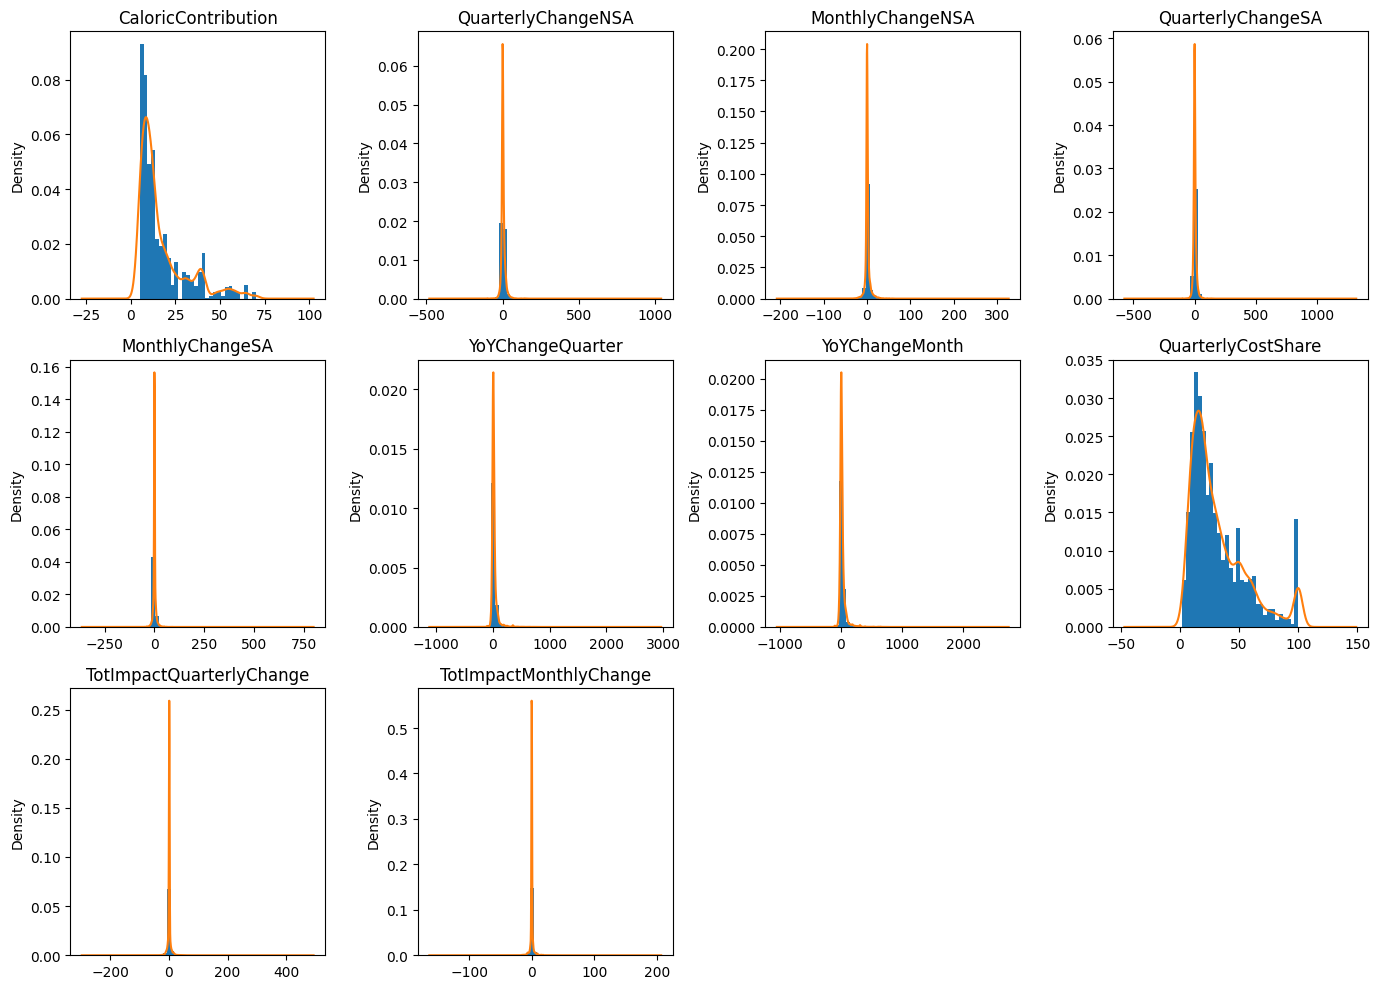

In [ ]:
#kurtosis
plt.figure(figsize=(14,10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)
    df[col].plot(kind='hist', bins=30, density=True)
    df[col].plot(kind='kde')
    plt.title(col)

plt.tight_layout()
plt.show()

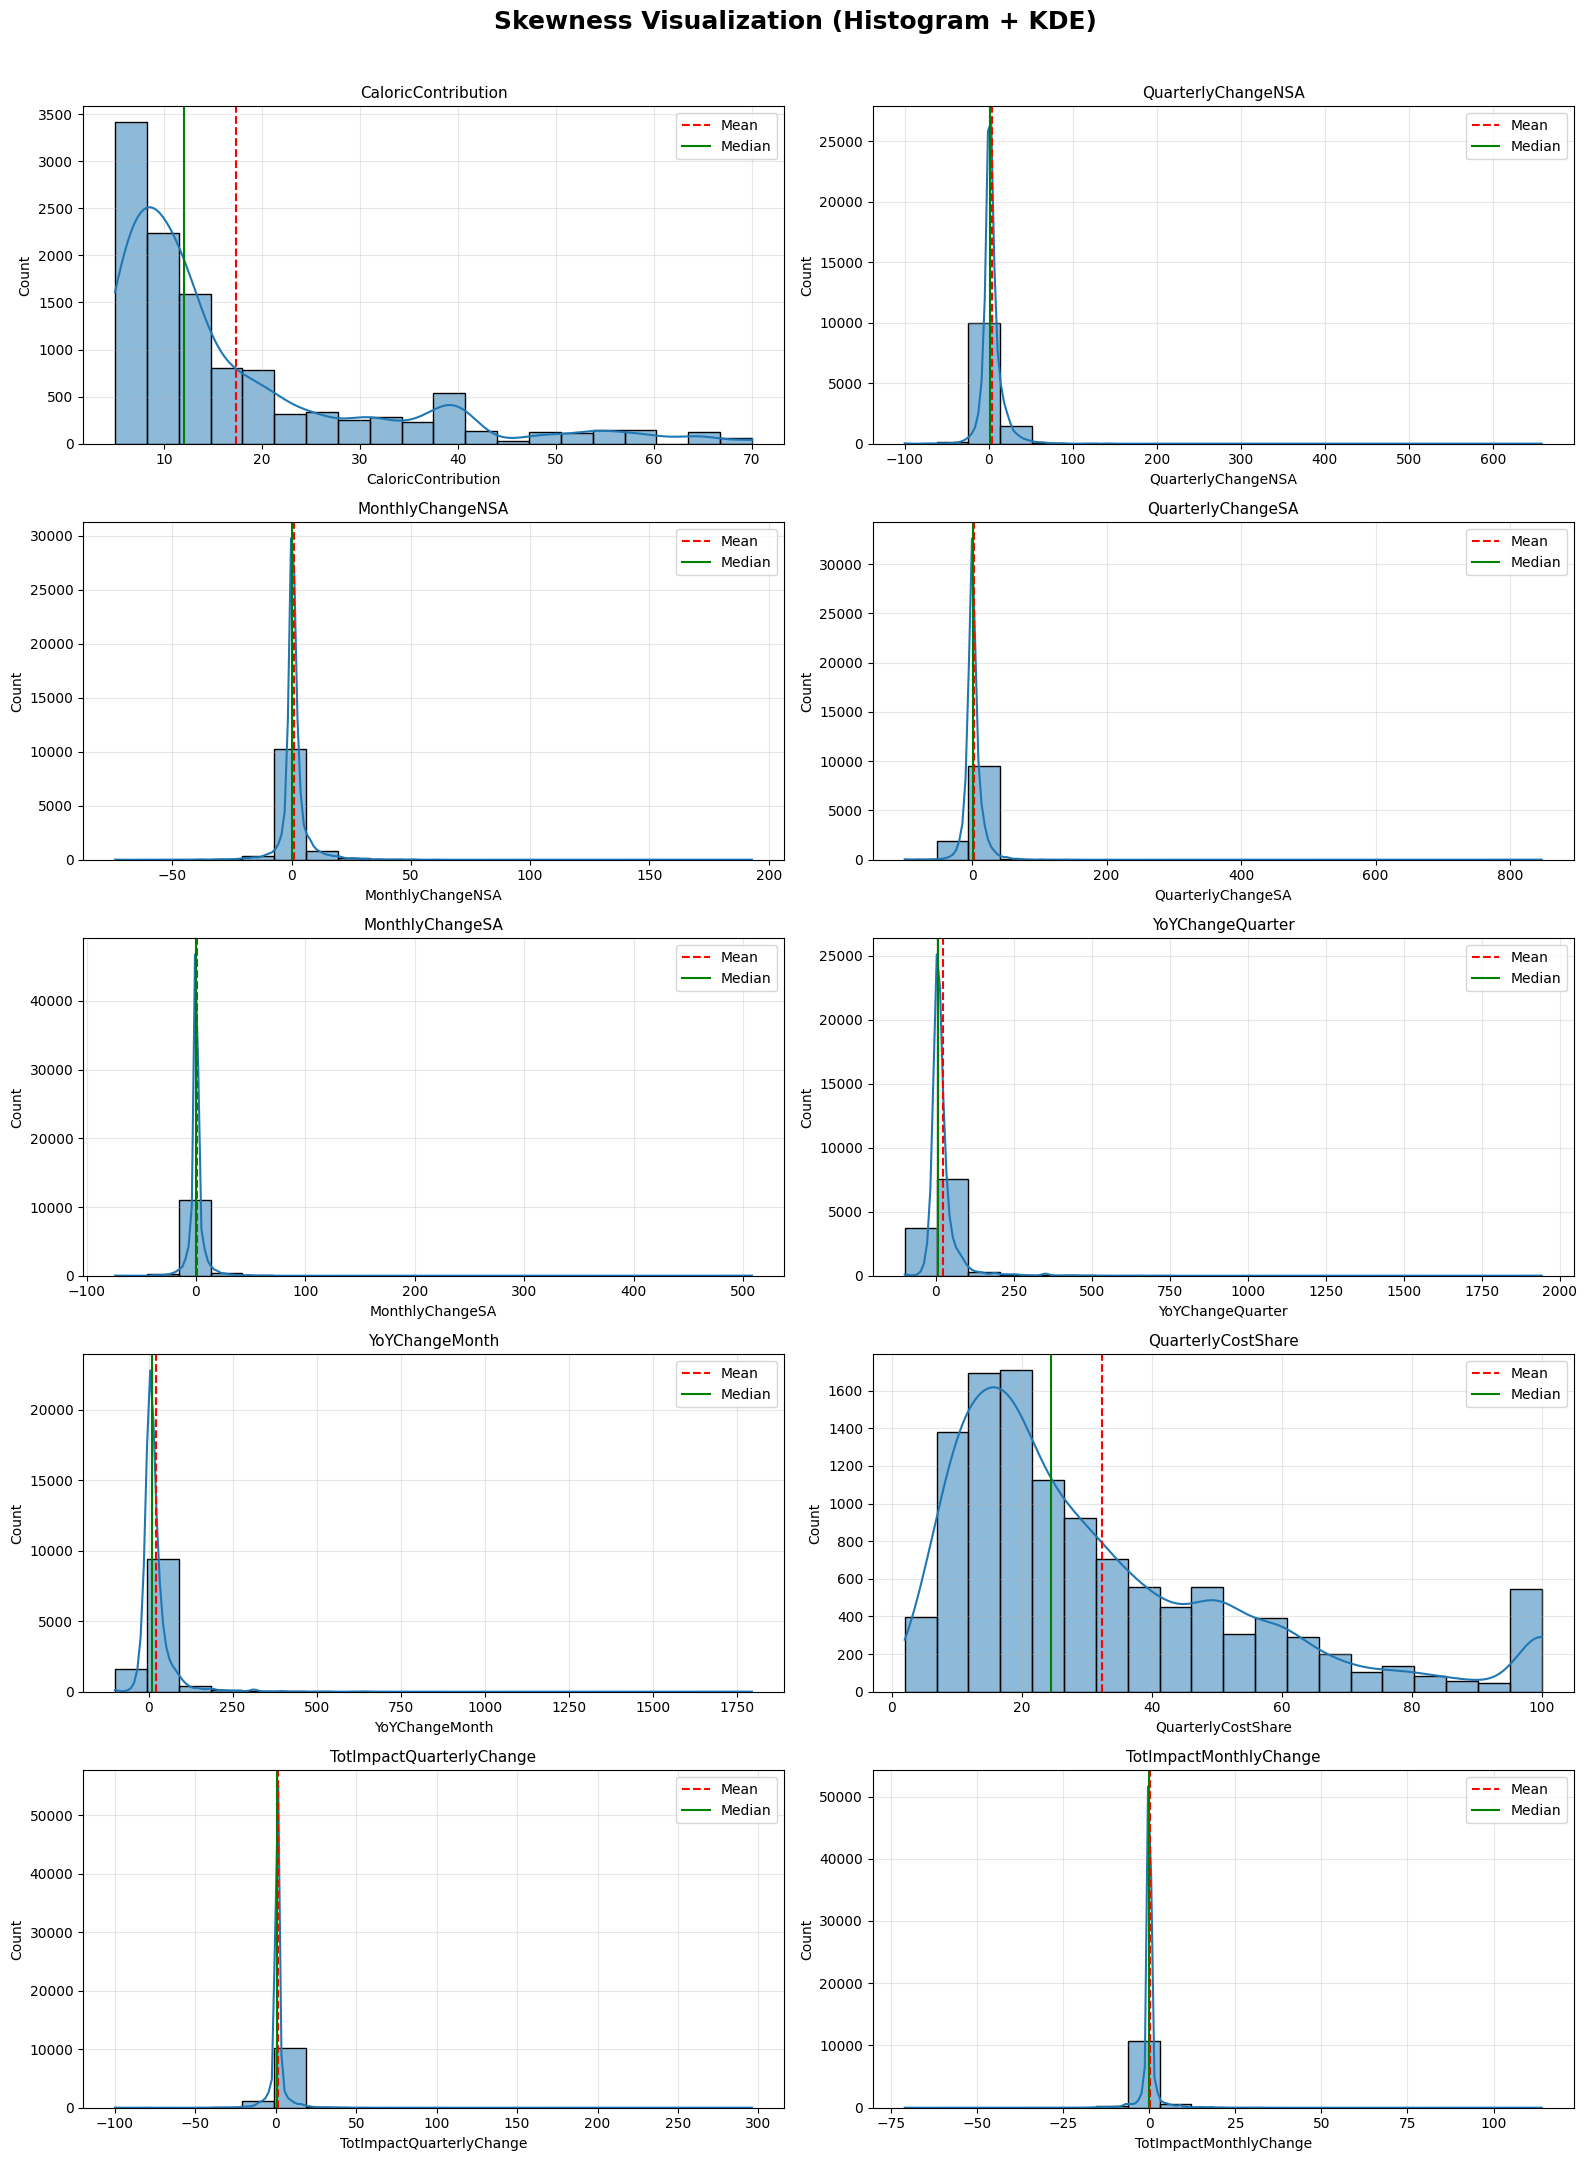

In [ ]:
#identify skewness chart representing the mean  and median value in lines
cols = ['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA',
        'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter',
        'YoYChangeMonth', 'QuarterlyCostShare',
        'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
fig.suptitle('Skewness Visualization (Histogram + KDE)',
             fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i])
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label='Median')
    axes[i].set_title(col, fontsize=11)
    axes[i].grid(alpha=0.3)
    axes[i].legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

skewness summary:
The dataset shows extreme positive skewness, indicating highly right-skewed distributions with heavy tails and significant outliers across most change-related variables.

In [ ]:
# MEASURE OF DISPERSION
# Variance and Standard Deviation
print('Variance:')
print(df[['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']].var())
print('\nStandard Deviation:')
print(df[['CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA', 'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter', 'YoYChangeMonth', 'QuarterlyCostShare', 'TotImpactQuarterlyChange', 'TotImpactMonthlyChange']].std())

Variance:
CaloricContribution          197.341666
QuarterlyChangeNSA           332.381317
MonthlyChangeNSA              44.762485
QuarterlyChangeSA            387.485886
MonthlyChangeSA               81.793937
YoYChangeQuarter            3410.140919
YoYChangeMonth              3641.452184
QuarterlyCostShare           572.410636
TotImpactQuarterlyChange      55.554406
TotImpactMonthlyChange        11.804419
dtype: float64

Standard Deviation:
CaloricContribution         14.047835
QuarterlyChangeNSA          18.231328
MonthlyChangeNSA             6.690477
QuarterlyChangeSA           19.684661
MonthlyChangeSA              9.044000
YoYChangeQuarter            58.396412
YoYChangeMonth              60.344446
QuarterlyCostShare          23.925105
TotImpactQuarterlyChange     7.453483
TotImpactMonthlyChange       3.435756
dtype: float64


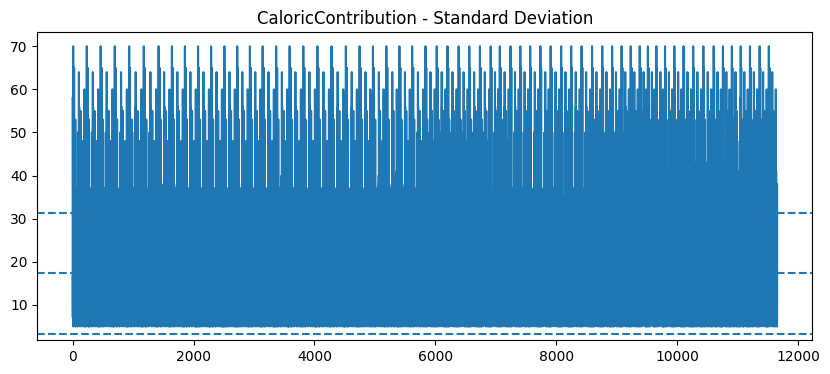

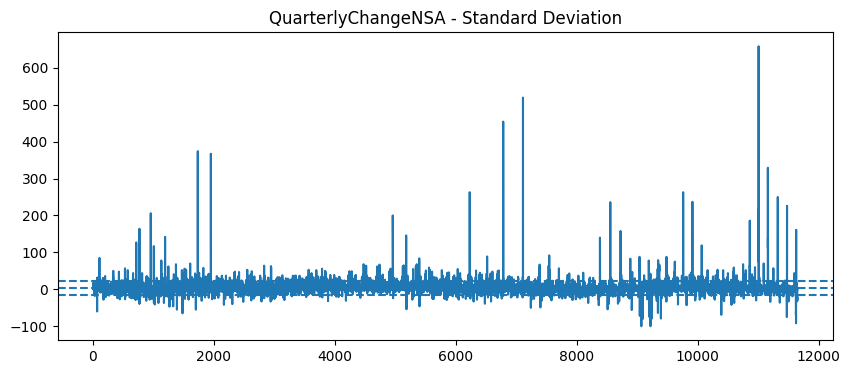

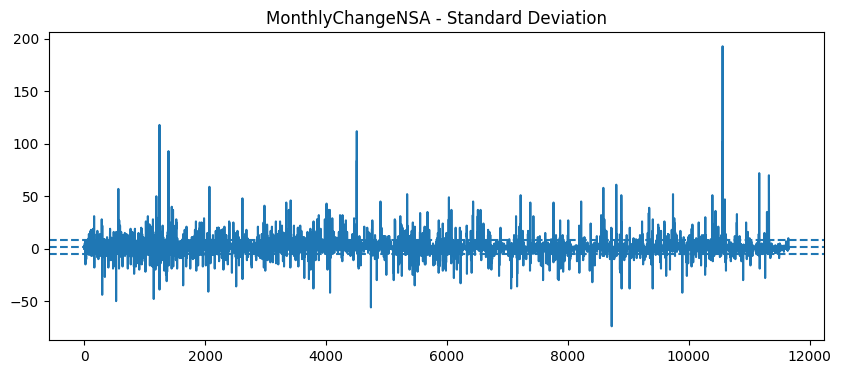

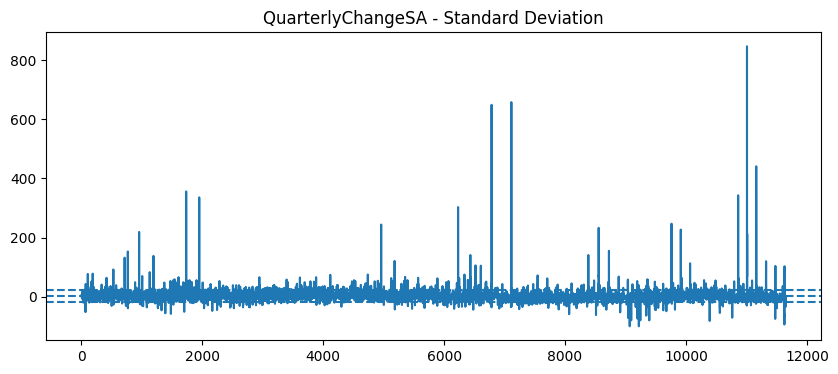

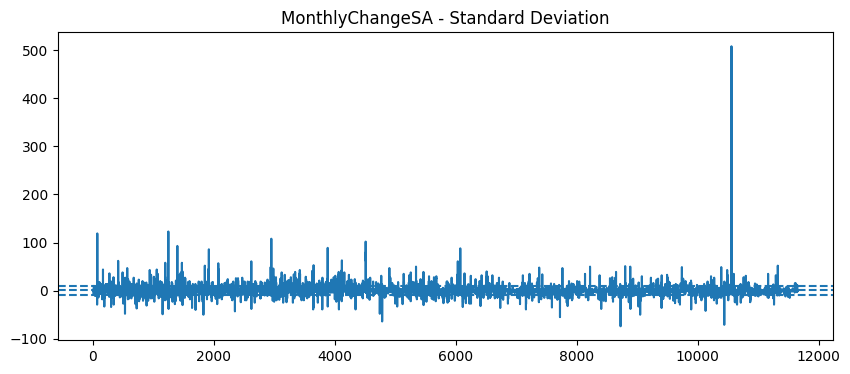

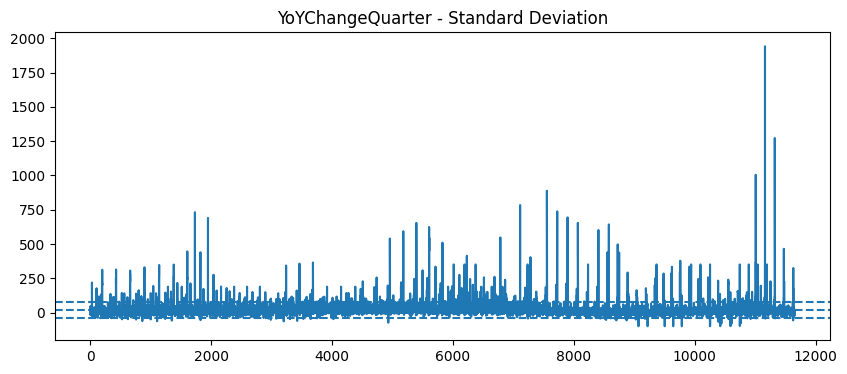

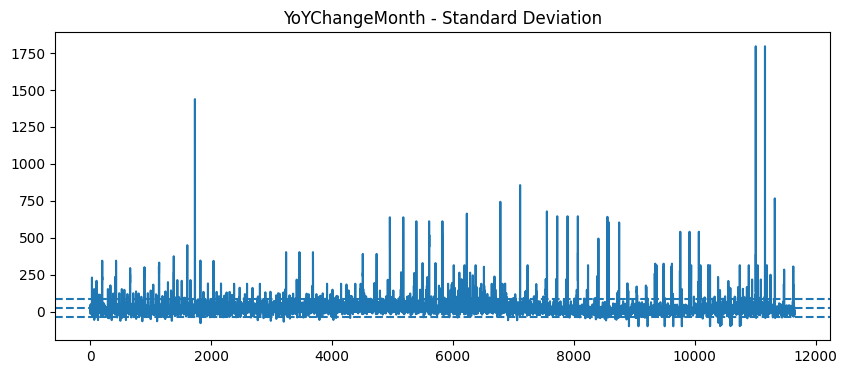

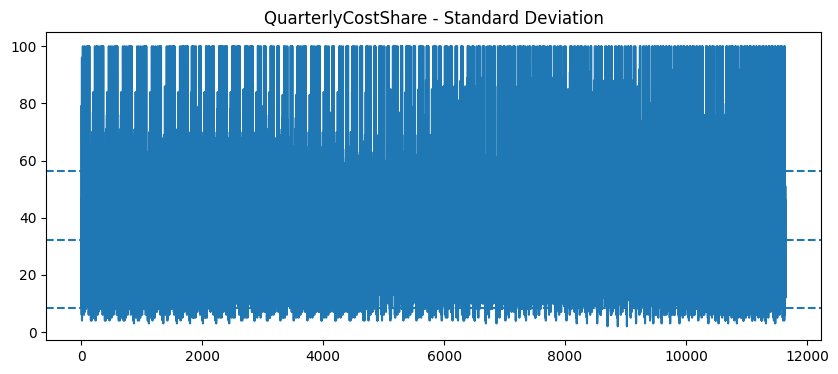

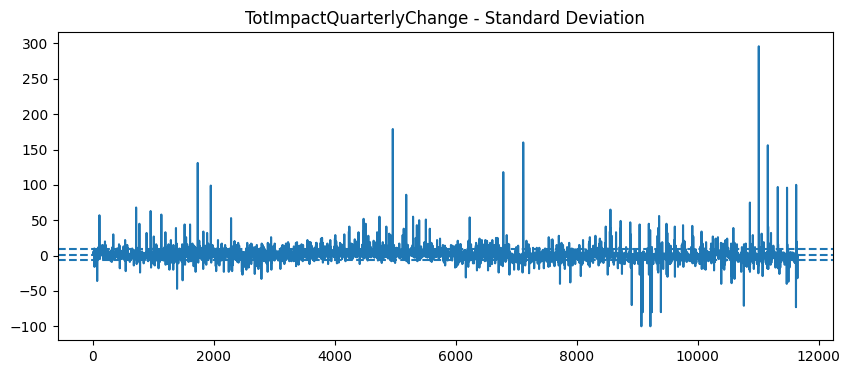

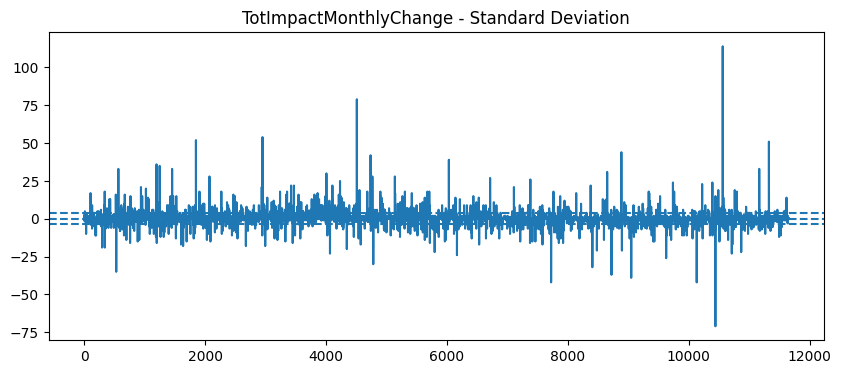

In [ ]:
#standard deviation
for col in cols:
    plt.figure(figsize=(10,4))

    mean = df[col].mean()
    std = df[col].std()

    plt.plot(df[col].values)
    plt.axhline(mean, linestyle='--')
    plt.axhline(mean + std, linestyle='--')
    plt.axhline(mean - std, linestyle='--')

    plt.title(f"{col} - Standard Deviation")
    plt.show()

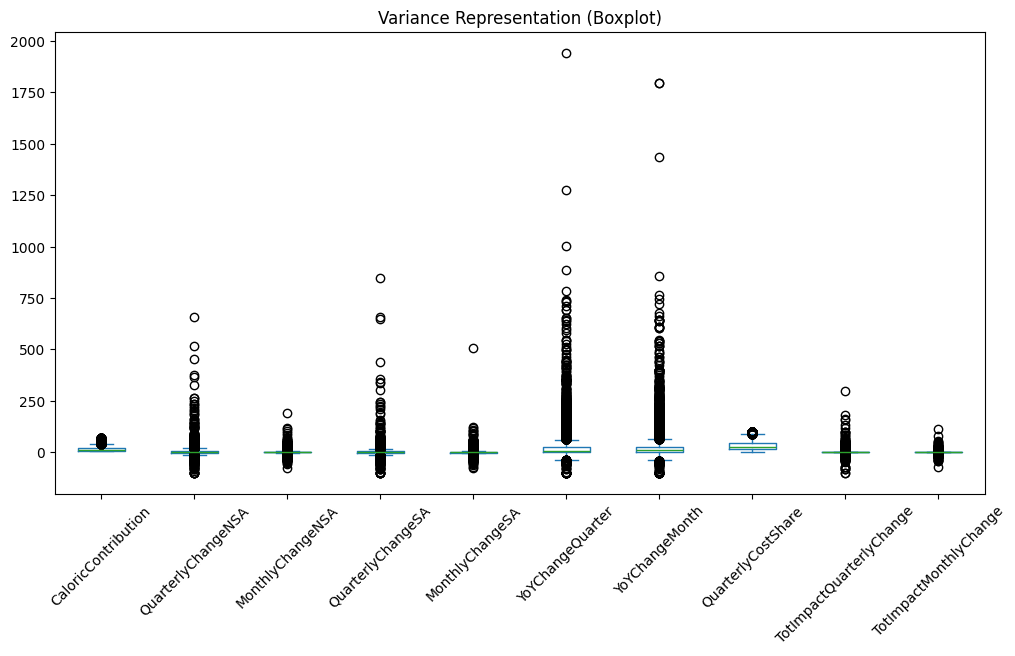

In [ ]:
#variance
df[cols].plot(kind='box', figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Variance Representation (Boxplot)")
plt.show()

The dataset shows extremely high variability, strong positive skewness, and heavy-tailed distributions, indicating large fluctuations and significant outliers especially in year-on-year and quarterly change variables

Clear Understanding of Your Dispersion Results

🔺 YoYChangeQuarter & YoYChangeMonth

Very high variance (3410, 3641)

Very high standard deviation (≈58–60)

➜ Indicates large fluctuations over time

🔺 QuarterlyChangeNSA & QuarterlyChangeSA

High variability (Std Dev ≈18–19)

➜ Strong quarterly volatility

🔹 MonthlyChange variables

Moderate variability compared to yearly data

🔹 TotImpactMonthlyChange

Lowest variance → More stable compared to others

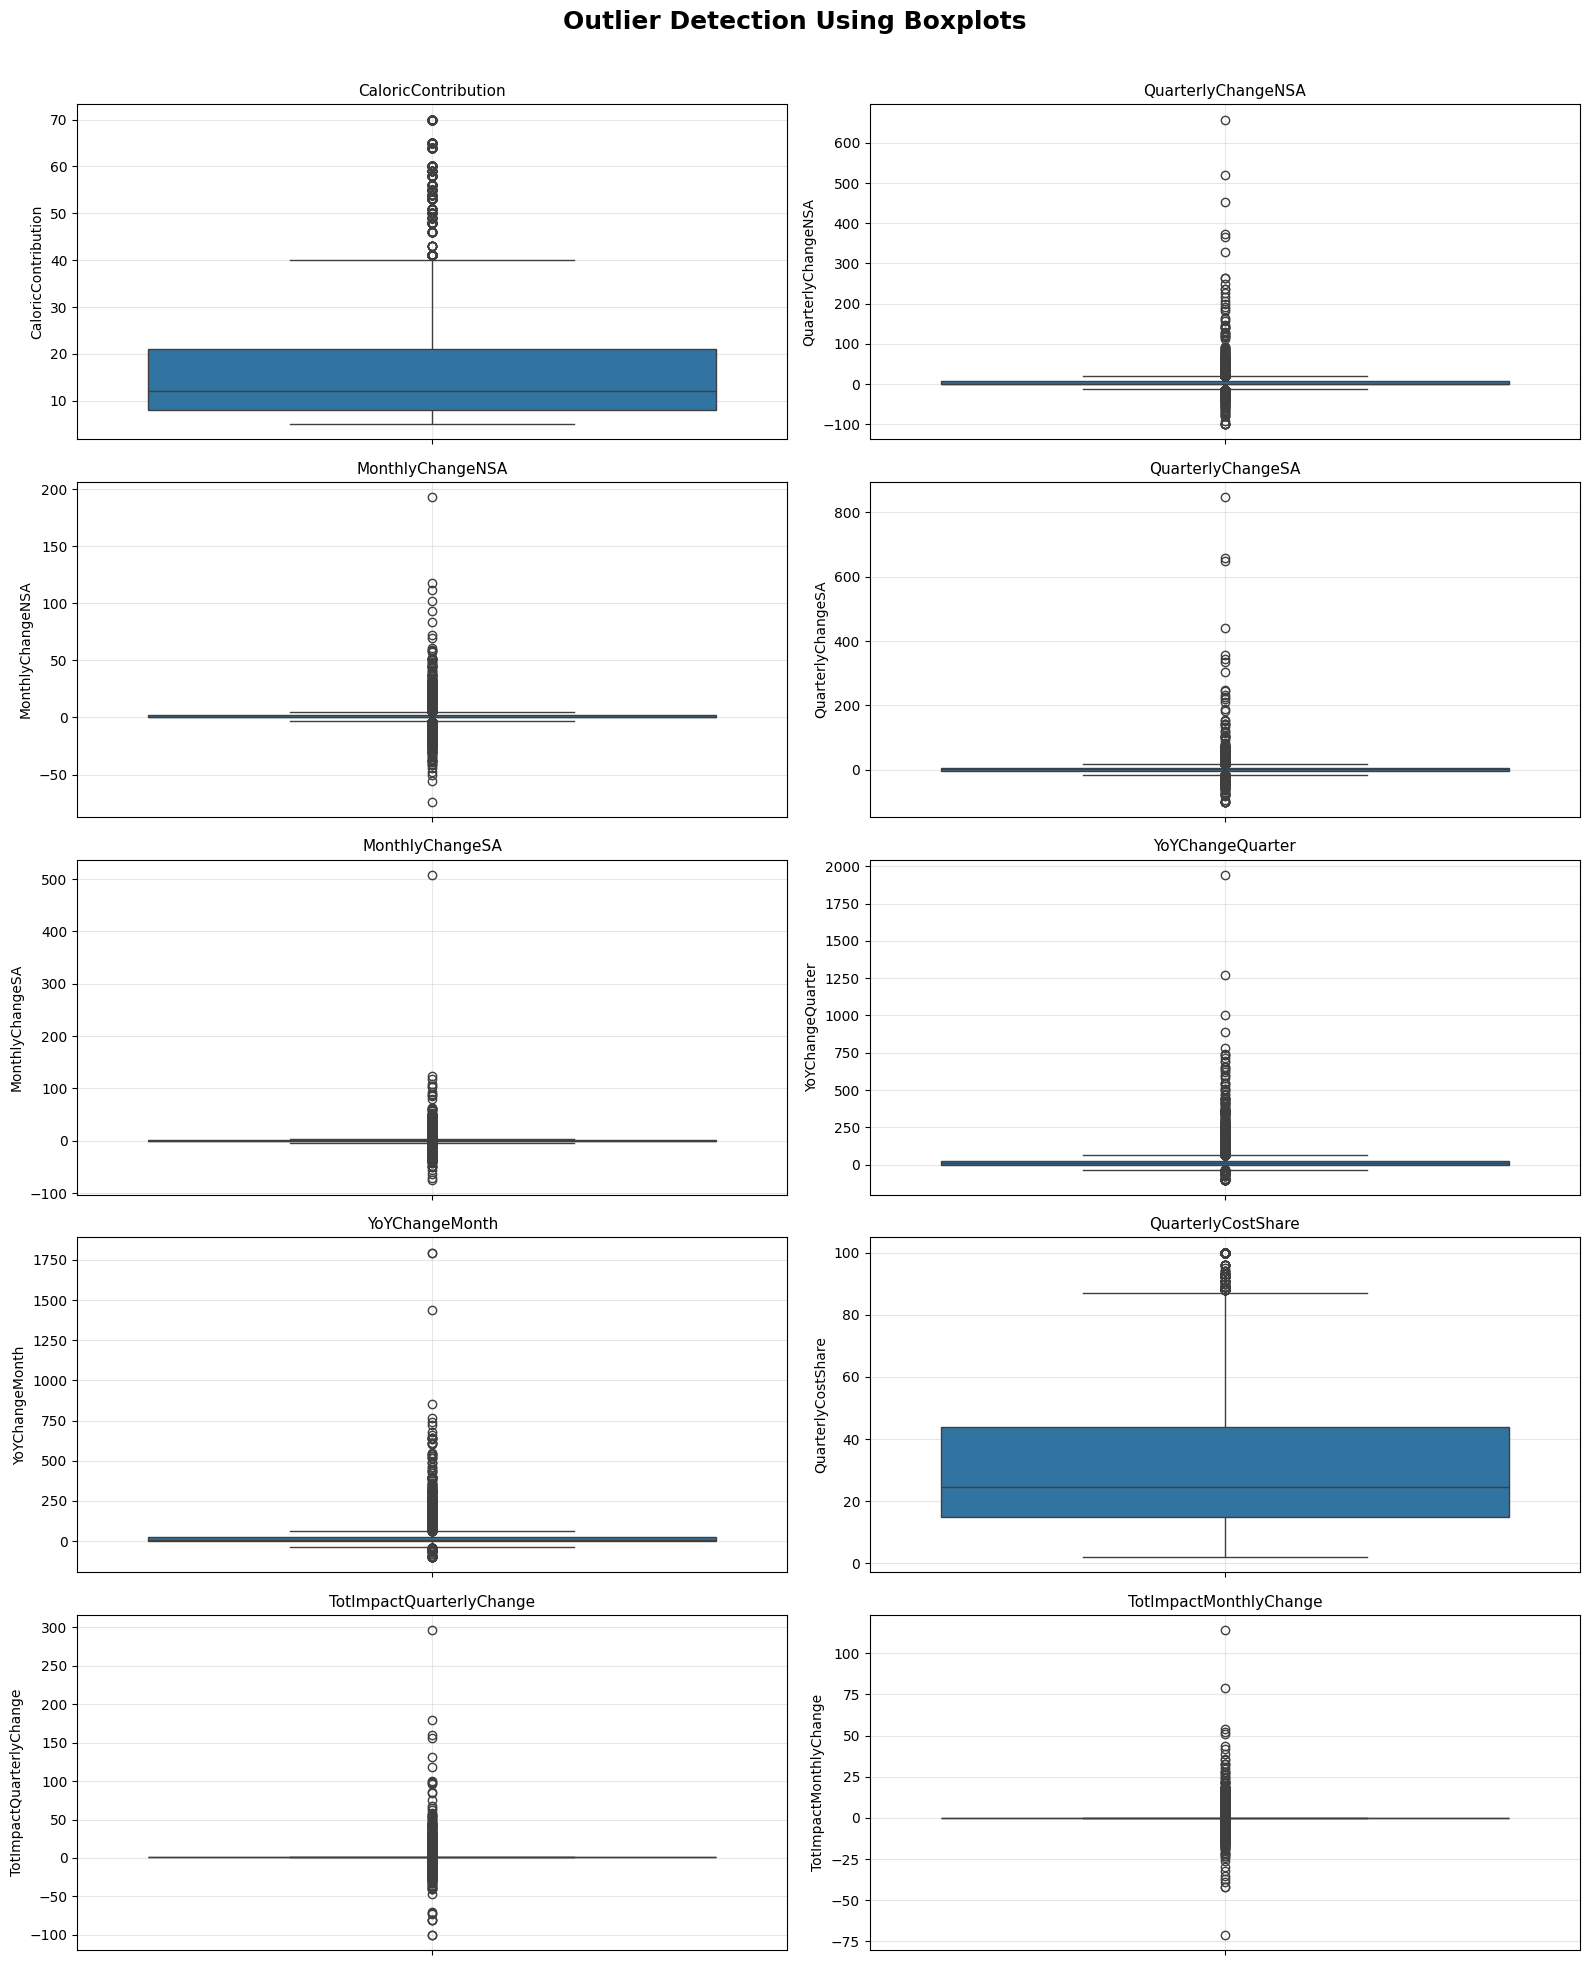

In [ ]:
#Outlier Detection – Boxplot Subplots
plt.style.use('default')

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fig.suptitle('Outlier Detection Using Boxplots', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Summarize Outliers
### Summary:
The boxplots reveal a prevalent presence of numerous positive outliers across most numerical columns, particularly in the change-related metrics (e.g., `YoYChangeQuarter`, `YoYChangeMonth`, `QuarterlyChangeNSA`), indicating significant upward fluctuations in food basket prices and their impacts.

**Visualizations**

Each Visualization Should Be in a Separate Cell

#1. Univariate Analysis (3–5 Visuals)

In [ ]:
sns.set_theme(
    style="dark",
    rc={
        "axes.facecolor": "#0A192F",
        "figure.facecolor": "#0A192F",
        "axes.edgecolor": "white",
        "axes.labelcolor": "white",
        "xtick.color": "white",
        "ytick.color": "white",
        "grid.color": "#2C3E50",
        "text.color": "white"
    }
)

**Interpretation**



1. Histogram – MonthlyChangeNSA

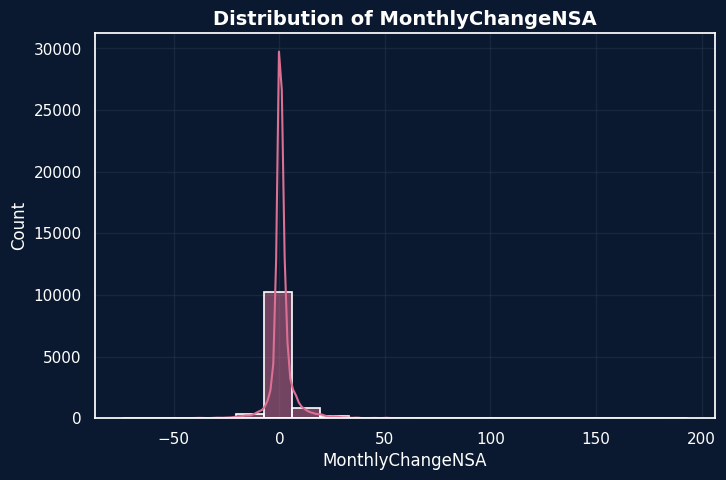

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyChangeNSA'],
             bins=20,
             kde=True,
             color="palevioletred",      # Bright blue
             edgecolor="white",
             linewidth=1.2)

plt.title("Distribution of MonthlyChangeNSA",
          fontsize=14, fontweight="bold")

plt.grid(alpha=0.4)
plt.show()

The'Distribution of MonthlyChangeNSA' histogram shows a highly right-skewed distribution, with most values concentrated around zero and a long tail extending towards positive monthly changes.

2. Boxplot – QuarterlyChangeNSA

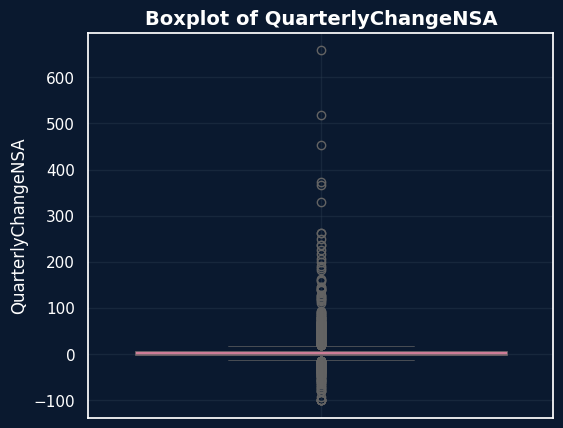

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df['QuarterlyChangeNSA'],
            color="palevioletred",
            linewidth=0.5)

plt.title("Boxplot of QuarterlyChangeNSA",
          fontsize=14, fontweight="bold")

plt.grid(alpha=0.4)
plt.show()

The Boxplot of QuarterlyChangeNSA indicates a distribution with a high concentration of data points near zero or slightly positive, but with a significant number of positive outliers, suggesting frequent upward price changes.

3. Year trend line plot

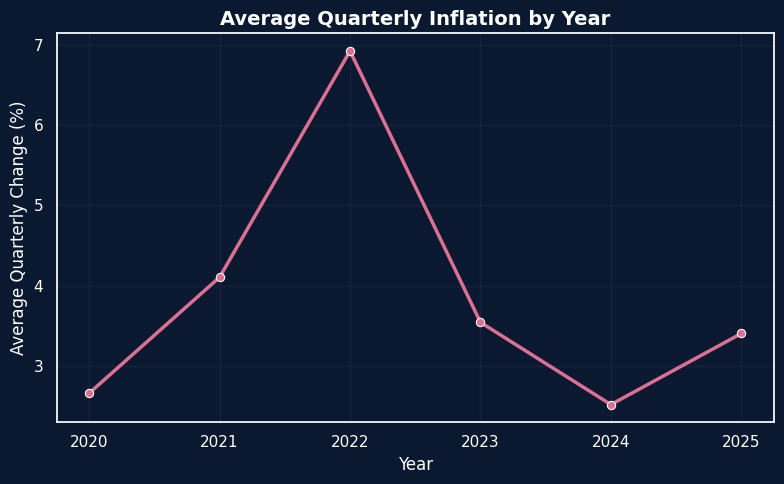

In [ ]:
plt.figure(figsize=(8,5))
year_trend = df.groupby('Year')['QuarterlyChangeNSA'].mean().sort_index()
sns.lineplot(
    x=year_trend.index,
    y=year_trend.values,
    marker='o',
    linewidth=2.5,
    color='palevioletred'
)

plt.title('Average Quarterly Inflation by Year',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Year')
plt.ylabel('Average Quarterly Change (%)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This trend line illustrates the long-term pattern and growth of average quarterly food price inflation over the years



4. Violin Plot – MonthlyChangeSA

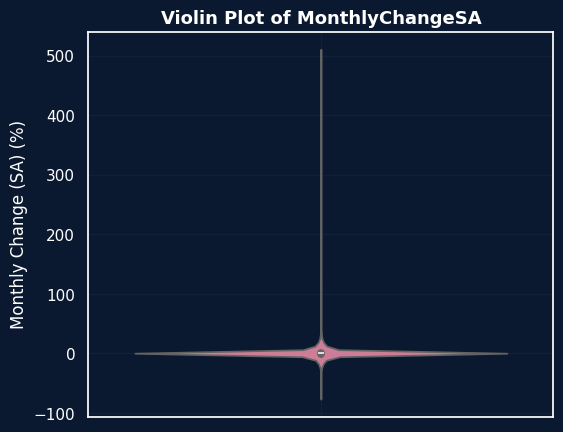

In [ ]:
plt.figure(figsize=(6,5))
sns.violinplot(y=df['MonthlyChangeSA'],color="palevioletred")
plt.title('Violin Plot of MonthlyChangeSA', fontsize=13, fontweight='bold')
plt.ylabel('Monthly Change (SA) (%)')
plt.xlabel('')                          # Optional: remove empty x-label

plt.grid(alpha=0.2)
plt.show()

The Violin Plot of MonthlyChangeSA illustrates a distribution highly concentrated around zero, with a significant spread and numerous outliers indicating both positive and negative monthly changes after seasonal adjustment.

5. Pie Chart – PriceTrendQuarter Distribution

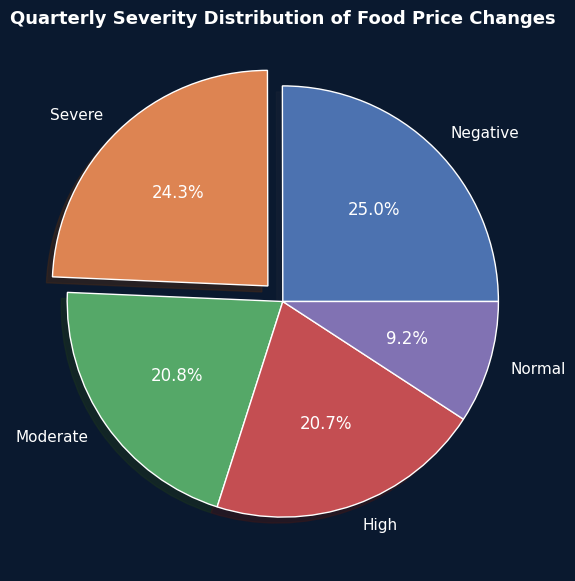

In [ ]:
severity_counts = df['SeverityCategory'].value_counts()

explode = [0.1 if label == 'Severe' else 0
           for label in severity_counts.index]

plt.figure(figsize=(7,7))

plt.pie(
    severity_counts,
    labels=severity_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    shadow=True
)

plt.title('Quarterly Severity Distribution of Food Price Changes',
          fontsize=13, fontweight='bold')

plt.show()

The pie chart shows the percentage distribution of quarterly food price changes across severity levels, highlighting severe inflation cases for food security monitoring.

#2. Bivariate Analysis

1. Stacked bar plot

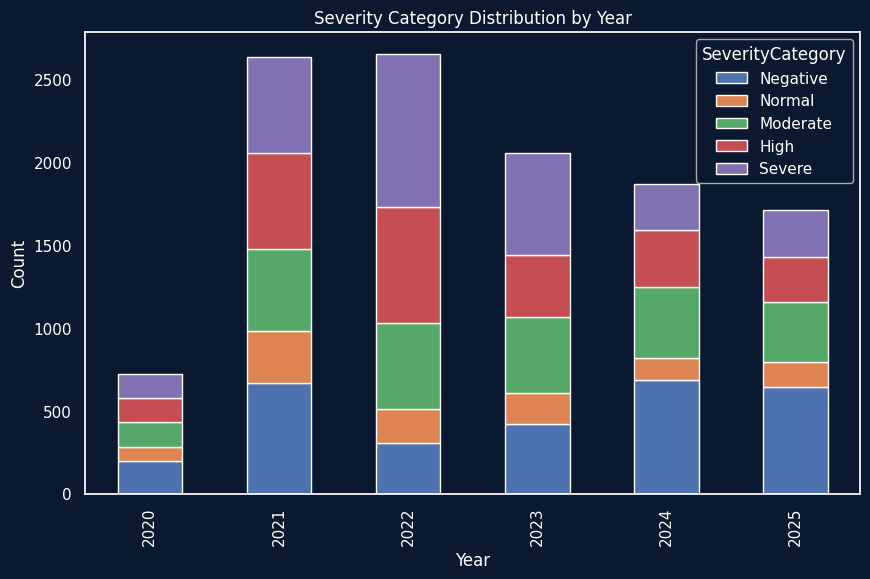

In [ ]:
severity_year = pd.crosstab(df['Year'], df['SeverityCategory'])

severity_year.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Severity Category Distribution by Year')
plt.ylabel('Count')
plt.show()

This stacked bar chart shows how inflation severity categories are distributed across different years, highlighting changes in risk levels over time.

2. line plot

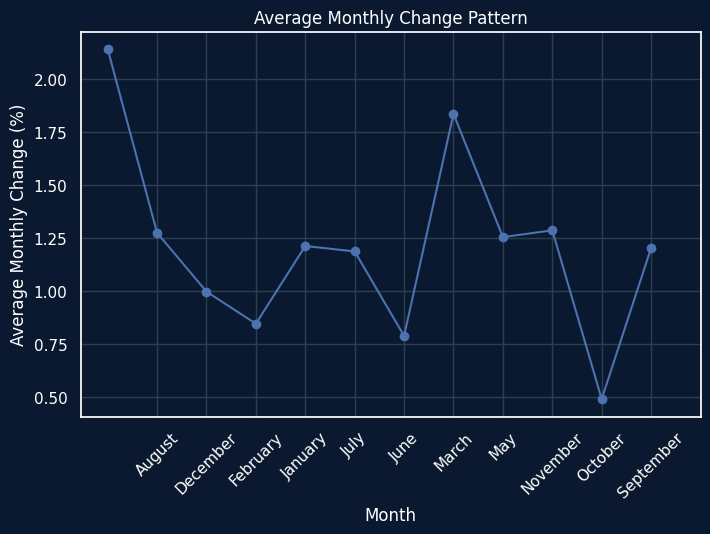

In [ ]:
month_trend = df.groupby('MonthName')['MonthlyChangeNSA'].mean()

plt.figure(figsize=(8,5))
plt.plot(month_trend.index, month_trend.values, marker='o')
plt.title('Average Monthly Change Pattern')
plt.xlabel('Month')
plt.ylabel('Average Monthly Change (%)')
plt.xticks(range(1,13), rotation = 45)
plt.grid(True)
plt.show()

This line chart shows the average monthly inflation pattern, highlighting seasonal price variations across months.

3. Regression Plot

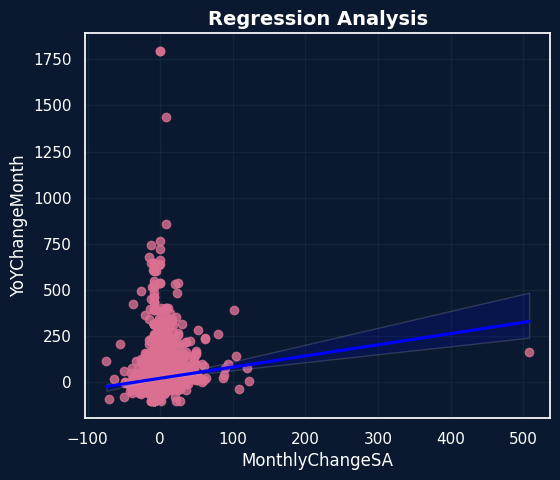

In [ ]:
plt.figure(figsize=(6,5))

sns.regplot(x=df['MonthlyChangeSA'],
            y=df['YoYChangeMonth'],
            scatter_kws={'color':"palevioletred"},
            line_kws={'color':"blue"})

plt.title("Regression Analysis",
          fontsize=14, fontweight="bold")

plt.grid(alpha=0.3)
plt.show()

The regression plot visualizes the linear relationship between MonthlyChangeSA and YoYChangeMonth, indicating how changes in one variable correspond to changes in the other.

4. Boxplot by Category

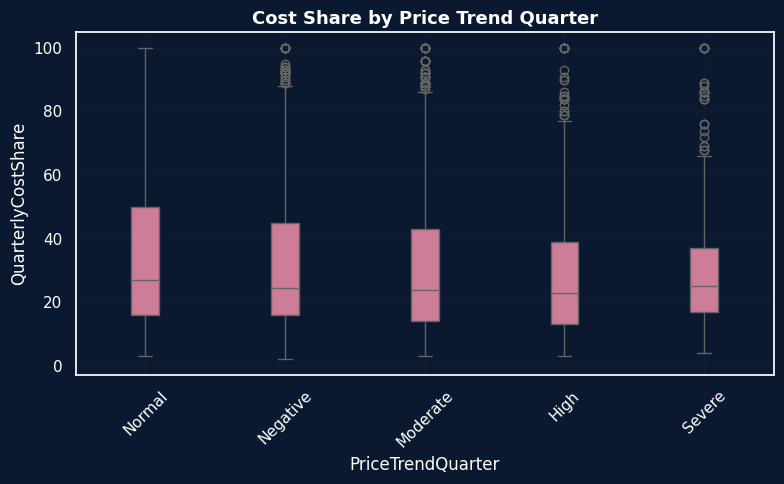

In [ ]:
plt.figure(figsize=(8,5))

# Glow layer (thick transparent layer)
sns.boxplot(x=df['PriceTrendQuarter'],
            y=df['QuarterlyCostShare'],
            color="palevioletred",
            width=0.2,
            linewidth=0.5, linecolor='white',
            fliersize=0)

# Main sharp layer
sns.boxplot(x=df['PriceTrendQuarter'],
            y=df['QuarterlyCostShare'],
            color='palevioletred',
            width=0.2)

plt.title('Cost Share by Price Trend Quarter',
          fontsize=13,
          fontweight='bold')

plt.xticks(rotation=45)
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

The 'Cost Share by Price Trend Quarter' boxplot illustrates the distribution of `QuarterlyCostShare` for each `PriceTrendQuarter` category, revealing how the cost share varies with different levels of price trend severity.

5. Bar Plot – Group Mean

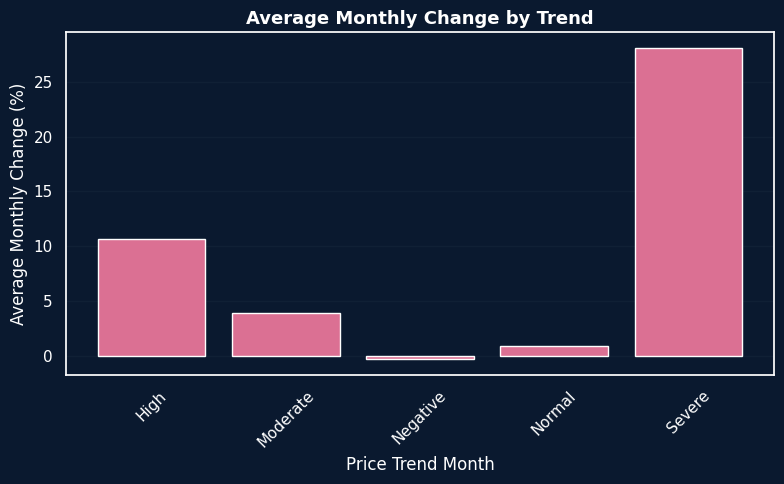

In [ ]:
avg_month = df.groupby('PriceTrendMonth')['MonthlyChangeNSA'].mean()

plt.figure(figsize=(8,5))

# Glow layer
plt.bar(avg_month.index,
        avg_month.values,
        color='palevioletred',
        alpha=0.25,
        linewidth=0)

# Main layer
plt.bar(avg_month.index,
        avg_month.values,
        color='palevioletred')

plt.title('Average Monthly Change by Trend',
          fontsize=13,
          fontweight='bold')
plt.xlabel('Price Trend Month')
plt.ylabel('Average Monthly Change (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

The 'Average Monthly Change by Trend' bar plot visualizes the average MonthlyChangeNSA across different PriceTrendMonth categories, allowing for a quick comparison of average monthly price fluctuations based on their trend.

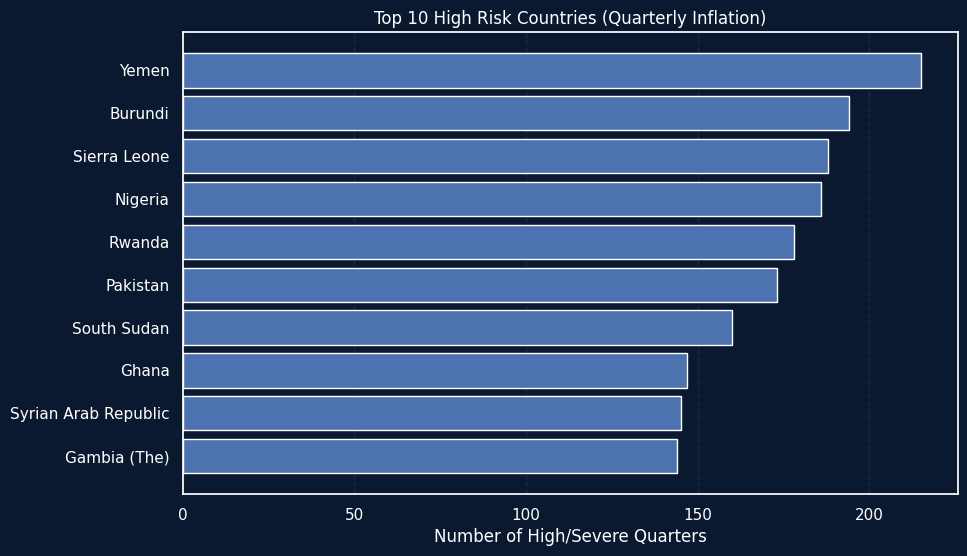

In [ ]:
high_risk_countries = df[df['SeverityCategory'].isin(['High', 'Severe'])]
top10_high_risk = high_risk_countries.groupby('CountryName')['SeverityCategory'].count().nlargest(10).reset_index()
top10_high_risk.columns = ['Country Name', 'High_Severe_Count']

plt.figure(figsize=(10,6))
plt.barh(top10_high_risk['Country Name'],
         top10_high_risk['High_Severe_Count'])

plt.xlabel("Number of High/Severe Quarters")
plt.title("Top 10 High Risk Countries (Quarterly Inflation)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

This chart identifies the countries experiencing the highest number of high and severe quarterly inflation periods.

#3. Multivariate Analysis (3 Visuals)

1. Correlation Heatmap

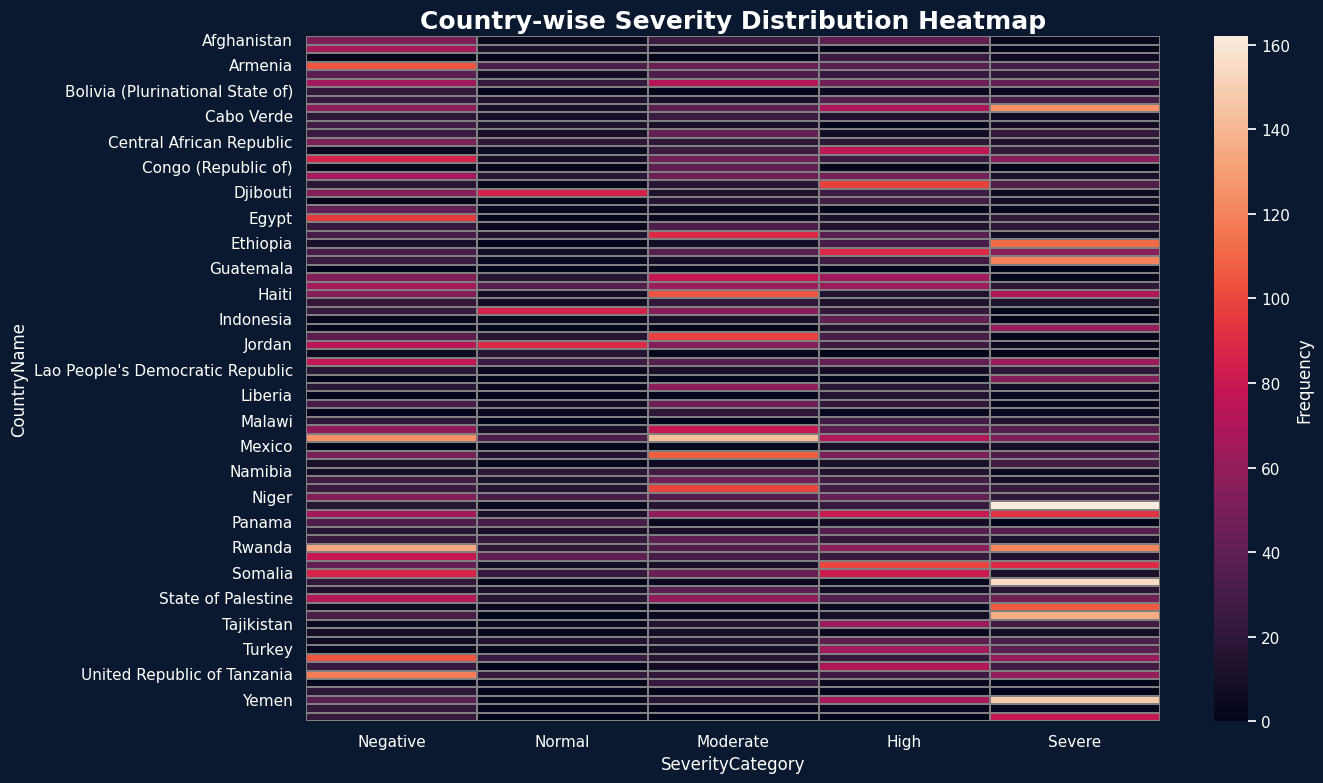

In [ ]:
severity_pivot = pd.crosstab(df['CountryName'], df['SeverityCategory'])

plt.figure(figsize=(14,8))

sns.heatmap(severity_pivot,
            cmap="rocket",
            linewidths=0.3,
            linecolor='gray',
            cbar_kws={'label': 'Frequency'})

plt.title("Country-wise Severity Distribution Heatmap",
          fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

This visualization displays the country-wise average quarterly inflation change using a heatmap to identify high-risk countries and inflation intensity over time.

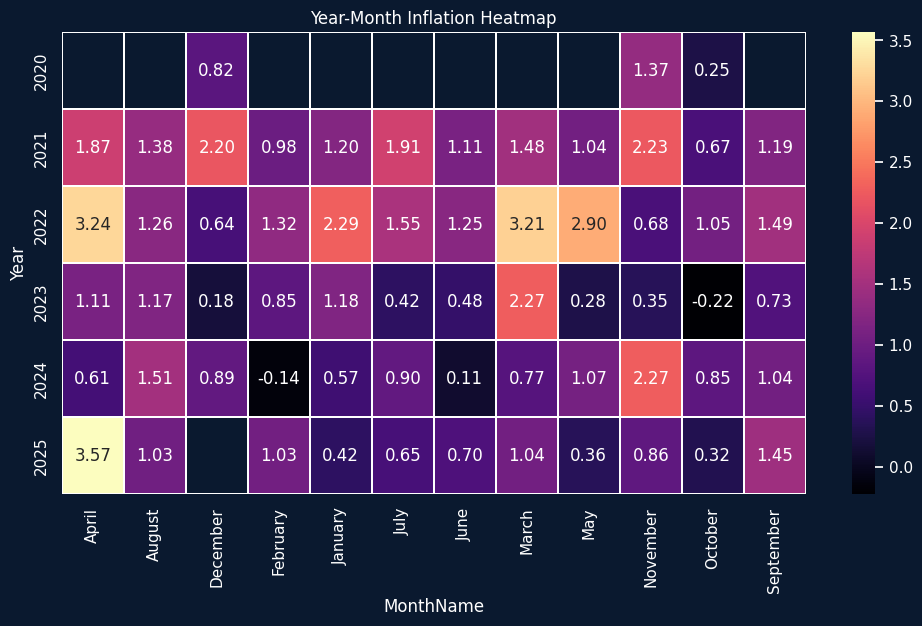

In [ ]:
pivot_table = df.pivot_table(values='MonthlyChangeNSA',
                             index='Year',
                             columns='MonthName',
                             aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(
    pivot_table,
    cmap='magma',
    linewidths=0.3,
    annot=True,          # show values inside
    fmt=".2f"            #format to 2 decimal places
)

plt.title('Year-Month Inflation Heatmap')
plt.xlabel('MonthName')
plt.ylabel('Year')
plt.show()

Darker colours = lower average inflation;
Brighter colours = higher average inflation

This heatmap displays average monthly inflation values across years, with annotated values highlighting the intensity of inflation in each period.

2. Pairplot

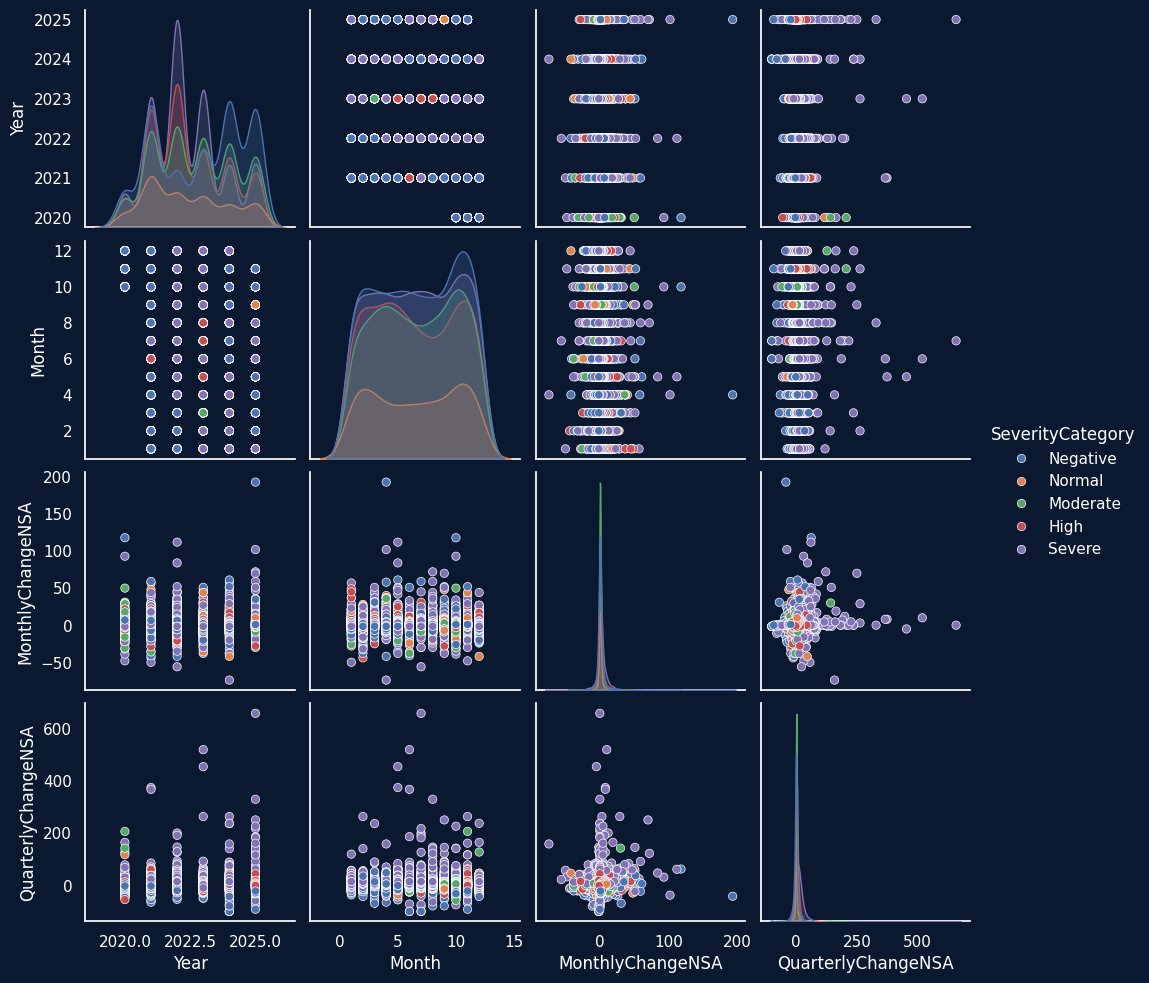

In [ ]:
sns.pairplot(
    df[['Year','Month','MonthlyChangeNSA','QuarterlyChangeNSA','SeverityCategory']],
    hue='SeverityCategory'
)
plt.show()

This pair plot visualizes the relationships between year, month, and inflation variables, highlighting how severity levels vary across time and price changes.

3. Bubble chart

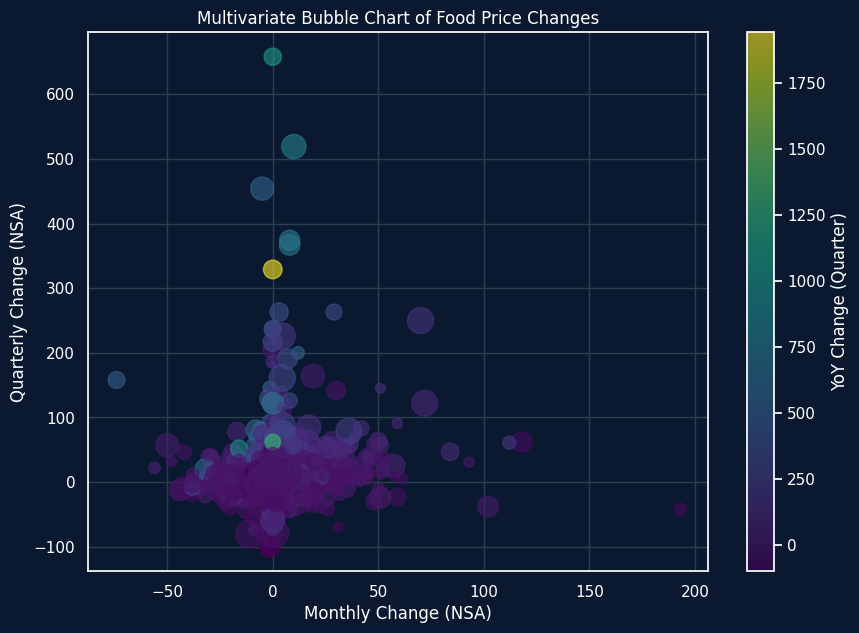

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df['MonthlyChangeNSA'],
    df['QuarterlyChangeNSA'],
    c=df['YoYChangeQuarter'],                 # color variable
    s=df['QuarterlyCostShare'] * 4,          # bubble size (scaled)
    cmap='viridis',
    alpha=0.6
)

plt.colorbar(scatter, label='YoY Change (Quarter)')

plt.title('Multivariate Bubble Chart of Food Price Changes')
plt.xlabel('Monthly Change (NSA)')
plt.ylabel('Quarterly Change (NSA)')

plt.grid(True)
plt.show()

The multivariate bubble chart visualizes the relationships between MonthlyChangeNSA, QuarterlyChangeNSA, YoYChangeQuarter (color), and QuarterlyCostShare (size), revealing complex interactions among these variables related to food basket price changes.

# **Stage 4**


**Documentation, Insights & Presentation**


**Summary of Findings:**

•	From 2021 to 2025, food basket prices changed differently across countries.

•	Most of the time, price increases were small or moderate. However, some countries experienced very high or severe increases, especially during certain quarters.

•	Staple foods like rice, wheat, maize, and cooking oil had the biggest impact on total food basket cost. When these prices increased, the overall basket cost also increased significantly.

•	Monthly prices showed short-term ups and downs, while quarterly prices showed long-term trends. Countries that frequently experienced high or severe quarterly increases are more vulnerable to food insecurity.

•	Overall, food inflation is influenced by import dependency, fuel prices, supply chain issues, and seasonal agricultural production.


Key Insights:

1.	Staple foods (rice, wheat, maize, oil) drive overall inflation.
2.	Most countries fall under Normal or Moderate price changes, but some face repeated High/Severe inflation.
3.	Monthly data shows short-term shocks, while quarterly data confirms sustained inflation.
4.	Import-dependent countries are more vulnerable to food price spikes.
5.	Repeated High/Severe quarters indicate potential food security risk.



**Types of Analysis**

Descriptive Analysis:

1.	Measured monthly and quarterly price percentage changes.
2.	Classified inflation into five severity levels.
3.	Identified distribution of Normal, Moderate, High, and Severe categories.
4.	Visualized price trends across countries.


Diagnostic Analysis:

1.	High cereal and oil prices increased total basket cost.
2.	Fuel price increases raised transportation costs.
3.	Climate changes affected vegetables and crop yields.
4.	Import dependency increased vulnerability.


Predictive Analysis:

1.	Countries with repeated High/Severe quarters may continue to face inflation.
2.	Rising oil and cereal prices may lead to future food basket increases.
3.	Monthly spikes may turn into sustained quarterly inflation.


Prescriptive Analysis:

1.	Maintain buffer stocks of staple foods.
2.	Improve local agricultural production.
3.	Diversify import sources.
4.	Implement targeted subsidies.
5.	Strengthen early warning monitoring systems.


**Recommendations / Decision Support:**

Based on the analysis:
1. Governments should monitor quarterly severity trends regularly.
2. Early warning alerts should be triggered for High/Severe categories.
3. Invest in storage, logistics, and domestic production.
4. Reduce dependence on imports where possible.
5. Provide financial support to vulnerable households during severe inflation periods.




**conclusion**

This study shows that food price increases are mainly caused by basic foods like rice, wheat, and cooking oil. Most of the time, prices changed normally or moderately. But in some countries, prices increased many times at high and severe levels. This can create food security problems.

So, it is important to monitor price changes every quarter. Governments should improve local food production, reduce import dependency, and create early warning systems. They should also support vulnerable families with financial help to control food prices and protect people.”